In [63]:
# Google Colab upload cell removed — dataset is loaded directly from file.
# Place ai_job_market_dataset.clean.xlsx in the same directory as this notebook.

In [64]:
import pandas as pd

df = pd.read_excel("ai_job_market_dataset.clean.xlsx", sheet_name="Sheet1")

print("Number of rows and columns (shape):")
print(df.shape)

print("Column names:")
print(df.columns.tolist())

display(df.head())

Number of rows and columns (shape):
(1696, 15)
Column names:
['Job IDs', 'title', 'company', 'location', 'category', 'contract_type', 'contract_time', 'salary_min', 'salary_max', 'salary_is_predicted', 'is_ai_related', 'salary_avg', 'created_date', 'currency', 'country_name']


,Job IDs,title,company,location,category,contract_type,contract_time,salary_min,salary_max,salary_is_predicted,is_ai_related,salary_avg,created_date,currency,country_name
0,5822242641,Senior Technologist Artificial Intelligence R ...,Hackajob Ltd,"Great Baddow, Chelmsford",Engineering Jobs,permanent,Not Specified,40000.00,40000.00,0,True,40000.00,2026-07-31,GBP,United Kingdom
1,5727313687,Artificial Intelligence,Adria Solutions,"Altrincham, Greater Manchester",IT Jobs,Not Specified,Not Specified,53702.83,53702.83,1,True,53702.83,2026-05-12,GBP,United Kingdom
2,5736675451,Artificial Intelligence Engineer,Oxford Dynamics,UK,IT Jobs,permanent,full_time,74422.25,74422.25,1,True,74422.25,2026-05-21,GBP,United Kingdom
3,5824444000,Artificial Intelligence Engineer,Quantiphi,"London, UK",IT Jobs,Not Specified,full_time,53031.54,53031.54,1,True,53031.54,2026-08-01,GBP,United Kingdom
4,5844156514,Artificial Intelligence Engineer,Discover International,"Monument, Central London",IT Jobs,contract,full_time,52000.00,60000.00,0,True,56000.00,2026-08-16,GBP,United Kingdom


In [65]:
print('Column data types:')
df.info()

Column data types:
<class 'pandas.DataFrame'>
RangeIndex: 1696 entries, 0 to 1695
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Job IDs              1696 non-null   int64         
 1   title                1696 non-null   str           
 2   company              1695 non-null   str           
 3   location             1696 non-null   str           
 4   category             1696 non-null   str           
 5   contract_type        1696 non-null   str           
 6   contract_time        1696 non-null   str           
 7   salary_min           1513 non-null   float64       
 8   salary_max           1513 non-null   float64       
 9   salary_is_predicted  1696 non-null   int64         
 10  is_ai_related        1696 non-null   bool          
 11  salary_avg           1513 non-null   float64       
 12  created_date         1696 non-null   datetime64[us]
 13  currency             1696

In [66]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

# Filter to show only columns with missing values and sort by percentage
missing_info = missing_info[missing_info['Missing Values'] > 0]
missing_info = missing_info.sort_values('Percentage', ascending=False)  # type: ignore[call-overload]

display(missing_info)

,Missing Values,Percentage
salary_min,183,10.790094
salary_max,183,10.790094
salary_avg,183,10.790094
company,1,0.058962


In [67]:
categorical_columns = [
    'is_ai_related',
    'country_name',
    'currency',
    'category',
    'contract_type',
    'contract_time',
    'salary_is_predicted'
]

for col in categorical_columns:
    print(f"\n--- Unique values and frequencies for '{col}' ---")
    vc = df[col].value_counts().reset_index()
    vc.columns = [col, 'Frequency']
    display(vc)


--- Unique values and frequencies for 'is_ai_related' ---


,is_ai_related,Frequency
0,True,1021
1,False,675



--- Unique values and frequencies for 'country_name' ---


,country_name,Frequency
0,United States,750
1,United Kingdom,746
2,India,200



--- Unique values and frequencies for 'currency' ---


...

,contract_type,Frequency
0,Not Specified,1264
1,permanent,289
2,contract,143



--- Unique values and frequencies for 'contract_time' ---


,contract_time,Frequency
0,Not Specified,870
1,full_time,685
2,part_time,141



--- Unique values and frequencies for 'salary_is_predicted' ---


,salary_is_predicted,Frequency
0,1,1161
1,0,535


In [68]:
numerical_salary_columns = ['salary_min', 'salary_max', 'salary_avg']

print("--- Descriptive statistics for salary columns ---")
salary_stats = df[numerical_salary_columns].describe().loc[['count', 'mean', '50%', 'min', 'max', 'std']]

display(salary_stats)

--- Descriptive statistics for salary columns ---


,salary_min,salary_max,salary_avg
count,1.513000e+03,1.513000e+03,1.513000e+03
mean,7.729904e+04,8.727796e+04,8.228850e+04
50%,5.460000e+04,5.514576e+04,5.500000e+04
min,0.000000e+00,1.300000e+01,1.300000e+01
max,2.000000e+06,5.000000e+06,3.500000e+06
std,9.713633e+04,1.836966e+05,1.375764e+05


### 1. Check for `salary_min > salary_max`

In [69]:
invalid_min_max = df[df['salary_min'] > df['salary_max']]

print(f"Number of rows where salary_min > salary_max: {len(invalid_min_max)}")
if not invalid_min_max.empty:
    print("Rows with salary_min > salary_max:")
    display(invalid_min_max[['salary_min', 'salary_max', 'salary_avg']])

Number of rows where salary_min > salary_max: 0


### 2. Check `salary_avg` calculation

In [70]:
# Filter rows where all three salary values are available
salary_present_df = df.dropna(subset=['salary_min', 'salary_max', 'salary_avg']).copy()

# Calculate the expected average
salary_present_df['expected_salary_avg'] = (salary_present_df['salary_min'] + salary_present_df['salary_max']) / 2

# Identify rows where the calculated average is different from the stored salary_avg
# Using `np.isclose` for float comparison to account for potential floating point inaccuracies
import numpy as np
incorrect_avg_calc = salary_present_df[~np.isclose(salary_present_df['salary_avg'], salary_present_df['expected_salary_avg'])]

print(f"Number of rows where salary_avg differs from (salary_min + salary_max) / 2: {len(incorrect_avg_calc)}")
if not incorrect_avg_calc.empty:
    print("Rows with incorrect salary_avg calculation:")
    display(incorrect_avg_calc[['salary_min', 'salary_max', 'salary_avg', 'expected_salary_avg']])

Number of rows where salary_avg differs from (salary_min + salary_max) / 2: 0


### 3. Display all rows failing either check

In [71]:
# Get Job IDs of rows failing each check
failed_check_1_ids = set(invalid_min_max['Job IDs'].tolist())
failed_check_2_ids = set(incorrect_avg_calc['Job IDs'].tolist())

# Combine the Job IDs from both checks
all_failed_ids = list(failed_check_1_ids.union(failed_check_2_ids))

print(f"Total unique rows failing either check: {len(all_failed_ids)}")
if all_failed_ids:
    display(df[df['Job IDs'].isin(all_failed_ids)][['Job IDs', 'salary_min', 'salary_max', 'salary_avg']])
else:
    print("No rows found that fail either check.")

Total unique rows failing either check: 0
No rows found that fail either check.


### 4. Display the 10 rows with the highest `salary_avg`

In [72]:
# Sort by 'salary_avg' in descending order and display the top 10
highest_salary_avg_rows = df.sort_values(by='salary_avg', ascending=False)
highest_salary_avg_rows = highest_salary_avg_rows.head(10)

print("Top 10 rows with the highest salary_avg values:")
display(highest_salary_avg_rows[['Job IDs', 'title', 'company', 'salary_min', 'salary_max', 'salary_avg', 'currency', 'country_name']])

Top 10 rows with the highest salary_avg values:


,Job IDs,title,company,salary_min,salary_max,salary_avg,currency,country_name
1575,4301976666,Artificial Intelligence (AI) Specialist,Forhyre,2000000.0,5000000.0,3500000.0,INR,India
1574,3466318331,Lead Artificial Intelligence Engineer,Xpressbees,1500000.0,2500000.0,2000000.0,INR,India
1534,1171508051,Artificial Intelligence Architect,Mastercard,1200000.0,1500000.0,1350000.0,INR,India
1644,2782428676,Senior Artificial intelligence/ Machine Learni...,Jobdost,800000.0,1800000.0,1300000.0,INR,India
1577,1173966364,NLP Engineer - Artificial Intelligence,Artivatic,1000000.0,1500000.0,1250000.0,INR,India
1512,3529447919,Artificial Intelligence,Randomtrees,1000000.0,1500000.0,1250000.0,INR,India
1643,1161627553,Senior Artificial Intelligence/Machine Learnin...,Artivatic,600000.0,1200000.0,900000.0,INR,India
1529,5341047558,Head - Artificial Intelligence,Kgisl Educational Institutions,100000.0,1500000.0,800000.0,INR,India
1642,1171509158,Artificial Intelligence/NLP/Machine Learning N...,Cogxio.Com,500000.0,1000000.0,750000.0,INR,India
1576,1161626890,NLP Engineer - Artificial Intelligence,Artivatic,500000.0,1000000.0,750000.0,INR,India


In [73]:
print('--- Value counts for is_ai_related ---')
print(df['is_ai_related'].value_counts())

print('\n--- Value counts for country_name ---')
print(df['country_name'].value_counts())

print('\n--- Value counts for currency ---')
print(df['currency'].value_counts())

print('\n--- Value counts for category ---')
print(df['category'].value_counts())

print('\n--- Value counts for contract_type ---')
print(df['contract_type'].value_counts())

print('\n--- Value counts for contract_time ---')
print(df['contract_time'].value_counts())

print('\n--- Value counts for salary_is_predicted ---')
print(df['salary_is_predicted'].value_counts())

--- Value counts for is_ai_related ---
is_ai_related
True     1021
False     675
Name: count, dtype: int64

--- Value counts for country_name ---
country_name
United States     750
United Kingdom    746
India             200
Name: count, dtype: int64

--- Value counts for currency ---
currency
USD    750
GBP    746
INR    200
Name: count, dtype: int64

--- Value counts for category ---
category
IT Jobs                             695
Engineering Jobs                    237
Admin Jobs                          202
Customer Services Jobs              153
Sales Jobs                          133
Accounting & Finance Jobs            59
Teaching Jobs                        31
Scientific & QA Jobs                 31
Part time Jobs                       28
Maintenance Jobs                     26
Legal Jobs                           19
Healthcare & Nursing Jobs            13
PR, Advertising & Marketing Jobs     11
Graduate Jobs                        10
HR & Recruitment Jobs                 9
Tr

## Business Question 1: How are job opportunities distributed between AI-related and non-AI-related jobs?


--- Distribution of AI-Related vs. Non-AI-Related Jobs ---


,Count,Percentage
is_ai_related,,
AI-Related,1021,60.200472
Non-AI-Related,675,39.799528


C:\Users\bhask\AppData\Local\Temp\ipykernel_20212\2400589736.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary_df.index, y='Count', data=summary_df, palette='viridis')


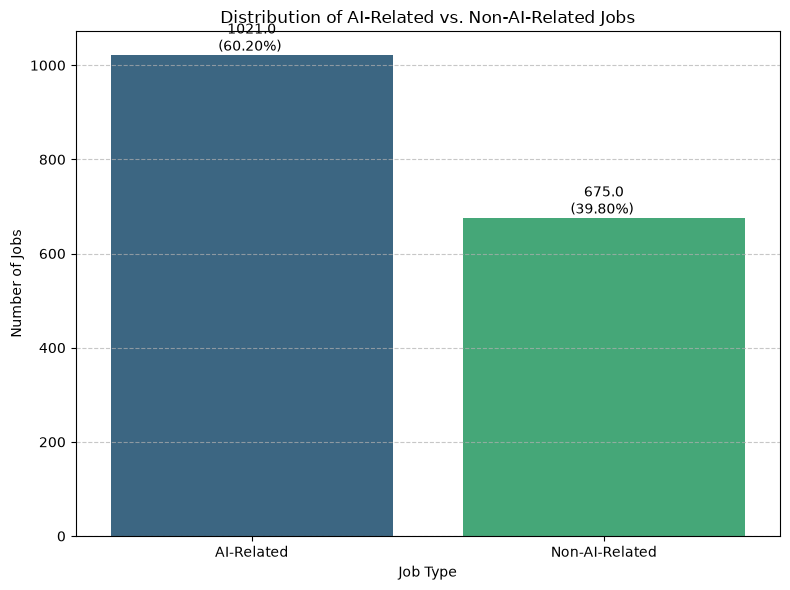

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the count of AI-related and non-AI-related jobs
ai_related_counts = df['is_ai_related'].value_counts()

# 2. Calculate their percentage of the total jobs
total_jobs = df.shape[0]
ai_related_percentages = (ai_related_counts / total_jobs) * 100

# Create a DataFrame for summary table
summary_data = {
    'Count': ai_related_counts,
    'Percentage': ai_related_percentages
}
summary_df = pd.DataFrame(summary_data)
summary_df.index = summary_df.index.map(lambda x: 'AI-Related' if x else 'Non-AI-Related')

print("\n--- Distribution of AI-Related vs. Non-AI-Related Jobs ---")
display(summary_df)

# 3. Create a bar chart comparing AI-related vs non-AI-related jobs
fig = plt.figure(figsize=(8, 6))
sns.barplot(x=summary_df.index, y='Count', data=summary_df, palette='viridis')
plt.title('Distribution of AI-Related vs. Non-AI-Related Jobs')
plt.xlabel('Job Type')
plt.ylabel('Number of Jobs')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)

# Add count and percentage labels on top of bars
for index, row in summary_df.iterrows():
    plt.text(str(index), float(row['Count']), f"{row['Count']}\n({row['Percentage']:.2f}%) ", color='black', ha="center", va='bottom')  # type: ignore[arg-type]

plt.tight_layout()
plt.show()

The bar chart visually represents the proportion of job opportunities that are AI-related versus non-AI-related. It clearly shows which category has more postings and by what margin, reinforcing the insights from the summary table.

## Business Question 2: How are AI-related and non-AI-related job opportunities distributed across the three countries in the dataset?


--- Distribution of AI-Related vs. Non-AI-Related Jobs per Country ---


,Total Jobs,AI-Related Jobs,Non-AI-Related Jobs,AI-Related (%),Non-AI-Related (%)
0,750,449,301,59.866667,40.133333
1,746,405,341,54.289544,45.710456
2,200,167,33,83.500000,16.500000


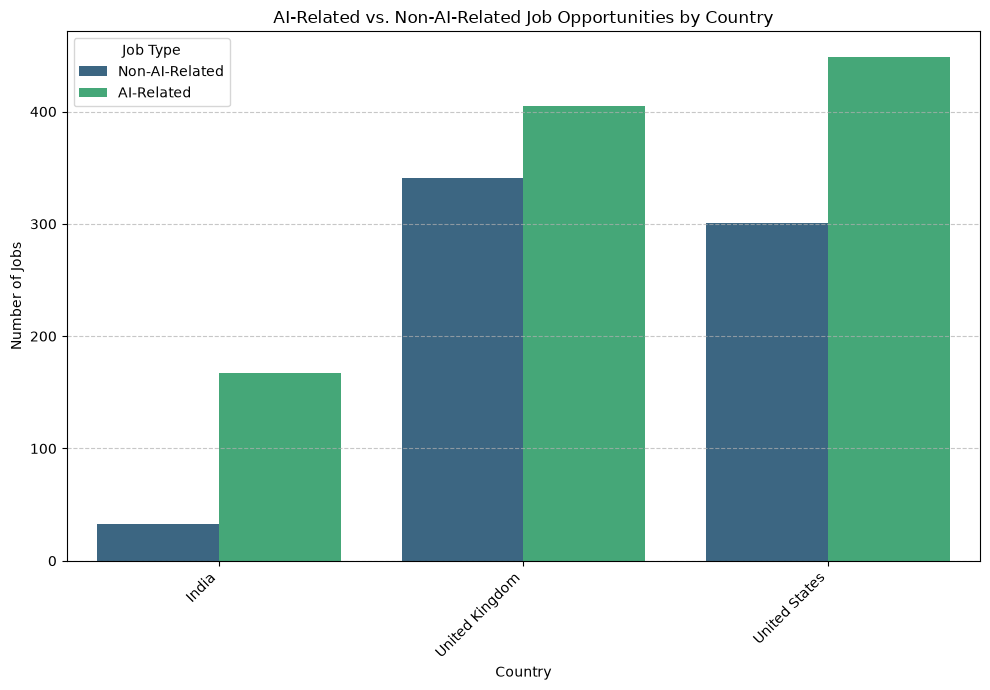

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the number of AI-related and non-AI-related jobs for each country_name
country_ai_counts = df.groupby(['country_name', 'is_ai_related']).size().unstack(fill_value=0)

# 2. Calculate the total jobs per country for percentage calculation
country_total_jobs = country_ai_counts.sum(axis=1)

# Calculate the percentage of AI-related and non-AI-related jobs within each country
country_ai_percentages = country_ai_counts.div(country_total_jobs, axis=0) * 100

# Combine counts and percentages into a more readable format for the summary table
summary_country_df = pd.DataFrame({
    'Total Jobs': country_total_jobs,
    'AI-Related Jobs': country_ai_counts[True],
    'Non-AI-Related Jobs': country_ai_counts[False],
    'AI-Related (%)': country_ai_percentages[True],
    'Non-AI-Related (%)': country_ai_percentages[False]
})

print("\n--- Distribution of AI-Related vs. Non-AI-Related Jobs per Country ---")
display(summary_country_df.sort_values('Total Jobs', ascending=False).reset_index(drop=True))  # type: ignore[call-overload]

# Prepare data for grouped bar chart
plot_df = country_ai_counts.stack().reset_index()
plot_df.columns = ['country_name', 'is_ai_related', 'count']
plot_df['is_ai_related'] = plot_df['is_ai_related'].map(lambda x: 'AI-Related' if x else 'Non-AI-Related')

# 3. Create a grouped bar chart
fig = plt.figure(figsize=(10, 7))
sns.barplot(x='country_name', y='count', hue='is_ai_related', data=plot_df, palette='viridis')
plt.title('AI-Related vs. Non-AI-Related Job Opportunities by Country')
plt.xlabel('Country')
plt.ylabel('Number of Jobs')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Job Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The grouped bar chart reveals the distribution of AI-related and non-AI-related jobs across the United States, United Kingdom, and India. The main pattern shown is how the proportion of AI-related jobs varies by country. The chart visually confirms the exact counts and percentages presented in the summary table, allowing for a quick comparison of job type distributions within each nation.

## Business Question 3: Which job categories have the highest number of AI-related and non-AI-related job opportunities?


--- Distribution of AI-Related vs. Non-AI-Related Jobs per Category ---


is_ai_related,False,True,Total Jobs
category,,,
IT Jobs,43,652,695
Engineering Jobs,11,226,237
Admin Jobs,196,6,202
Customer Services Jobs,152,1,153
Sales Jobs,109,24,133
Accounting & Finance Jobs,42,17,59
Scientific & QA Jobs,2,29,31
Teaching Jobs,11,20,31
Part time Jobs,28,0,28


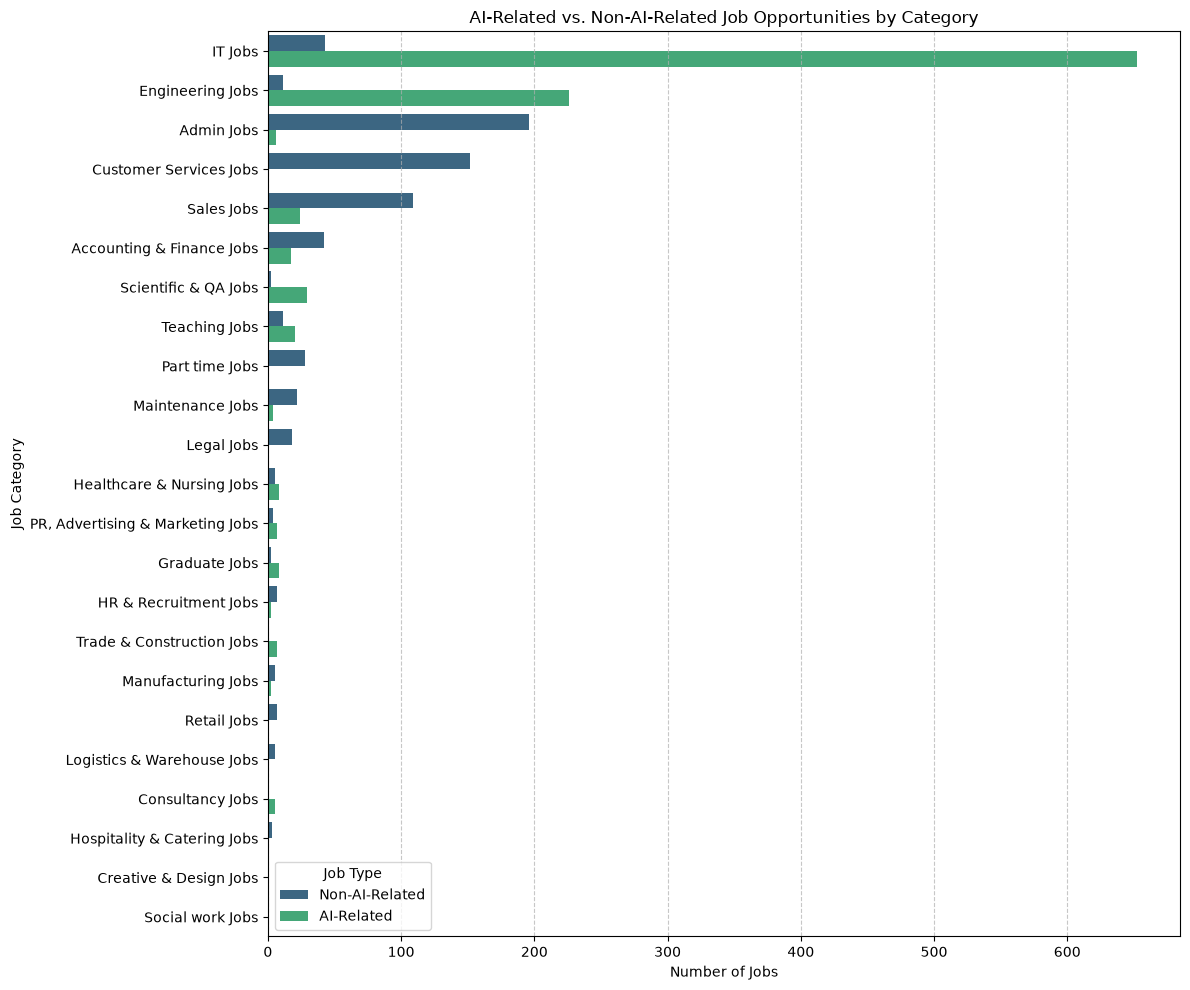

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group jobs by `category` and `is_ai_related` and calculate counts
category_ai_counts = df.groupby(['category', 'is_ai_related']).size().unstack(fill_value=0)

# Calculate total jobs per category
category_ai_counts['Total Jobs'] = category_ai_counts[True] + category_ai_counts[False]

# 3. Sort the categories by total number of jobs, from highest to lowest
sorted_category_ai_counts = category_ai_counts.sort_values('Total Jobs', ascending=False)  # type: ignore[call-overload]
sorted_category_ai_counts = sorted_category_ai_counts.copy()

# Display the resulting summary table
print("\n--- Distribution of AI-Related vs. Non-AI-Related Jobs per Category ---")
display(sorted_category_ai_counts)

# Prepare data for grouped bar chart
plot_df_category = sorted_category_ai_counts.drop(columns='Total Jobs').stack().reset_index()
plot_df_category.columns = ['category', 'is_ai_related', 'count']
plot_df_category['is_ai_related'] = plot_df_category['is_ai_related'].map(lambda x: 'AI-Related' if x else 'Non-AI-Related')

# 4. Create a horizontal grouped bar chart
fig = plt.figure(figsize=(12, 10)) # Adjust figure size for better readability
sns.barplot(x='count', y='category', hue='is_ai_related', data=plot_df_category, palette='viridis', orient='h')
plt.title('AI-Related vs. Non-AI-Related Job Opportunities by Category')
plt.xlabel('Number of Jobs')
plt.ylabel('Job Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Job Type')
plt.tight_layout()
plt.show()

The horizontal grouped bar chart visually represents the number of AI-related and non-AI-related jobs within each job category, sorted by the total number of jobs. The main patterns visible in the data include: the dominance of 'IT Jobs' in both AI-related and non-AI-related roles, and how the proportion of AI-related jobs varies across different categories.

## Business Question 4: How do salaries differ between AI-related and non-AI-related jobs within each country?

--- Salary Analysis: Median and Mean Salaries by Country and AI-Related Status ---


,country_name,is_ai_related,job_count,median_salary,mean_salary,is_ai_related_label
0,India,True,17,750000.00,992941.176471,AI-Related
1,United Kingdom,False,341,27091.05,31702.725044,Non-AI-Related
2,United Kingdom,True,405,57500.00,63318.173630,AI-Related
3,United States,False,301,40624.72,43466.039169,Non-AI-Related
4,United States,True,449,124965.99,129364.665501,AI-Related


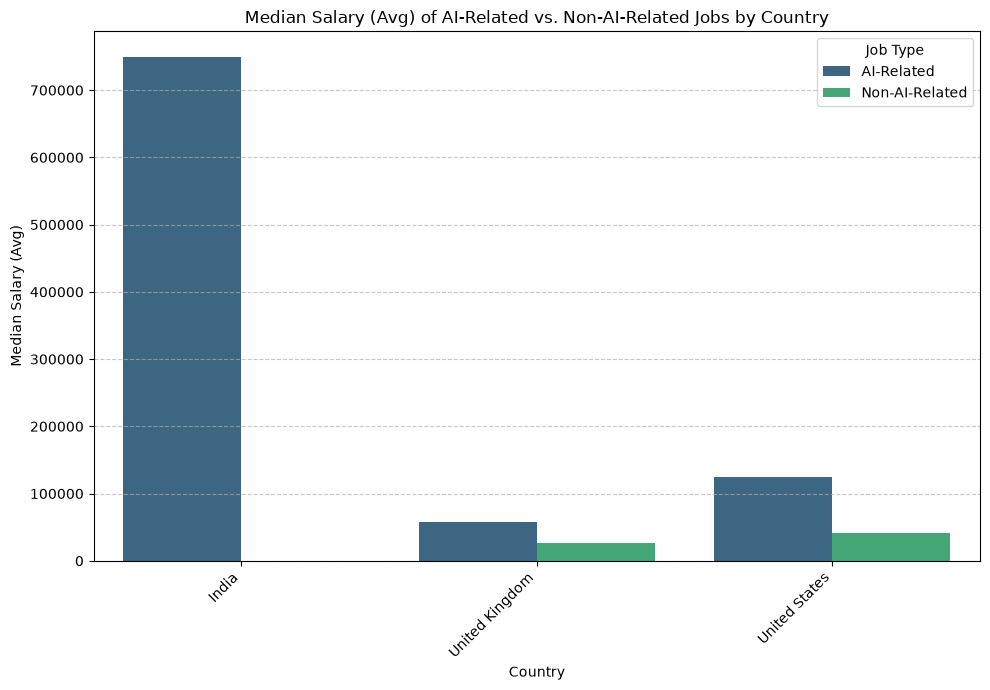

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out rows where 'salary_avg' is NaN for accurate salary comparison
salary_df = df.dropna(subset=['salary_avg']).copy()

# Group by country and 'is_ai_related', then calculate median, mean, and count of jobs
salary_analysis = salary_df.groupby(['country_name', 'is_ai_related']).agg(
    job_count=('Job IDs', 'count'),
    median_salary=('salary_avg', 'median'),
    mean_salary=('salary_avg', 'mean')
).reset_index()

# Map boolean 'is_ai_related' to descriptive strings for better readability in the plot
salary_analysis['is_ai_related_label'] = salary_analysis['is_ai_related'].map(lambda x: 'AI-Related' if x else 'Non-AI-Related')

print("--- Salary Analysis: Median and Mean Salaries by Country and AI-Related Status ---")
display(salary_analysis)

# Create a grouped bar chart for median salaries
fig = plt.figure(figsize=(10, 7))
sns.barplot(x='country_name', y='median_salary', hue='is_ai_related_label', data=salary_analysis, palette='viridis')

plt.title('Median Salary (Avg) of AI-Related vs. Non-AI-Related Jobs by Country')
plt.xlabel('Country')
plt.ylabel('Median Salary (Avg)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Job Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The grouped bar chart illustrates the median salary differences between AI-related and non-AI-related jobs by country. Within the United Kingdom (GBP), the AI-related median salary is £57,500 compared to £27,091.05 for non-AI-related roles. Within the United States (USD), the AI-related median salary is $124,965.99 compared to $40,624.72 for non-AI-related roles. India is excluded from the AI vs. non-AI salary comparison: only 17 AI salary observations are available and there are zero non-AI salary observations, which is insufficient for a valid comparison. Currencies are not converted and no cross-country salary comparisons are made.

## Business Question 5: How does employment structure differ between AI-related and non-AI-related jobs?

### 1. Comparison of `contract_type`

--- Contract Type Distribution by Job Type (Counts and Percentages) ---


Counts                      Percentages             \
contract_type  Not Specified contract permanent Not Specified   contract   
is_ai_related                                                              
Non-AI-Related           448       71       156     66.370370  10.518519   
AI-Related               816       72       133     79.921645   7.051910   

                           
contract_type   permanent  
is_ai_related              
Non-AI-Related  23.111111  
AI-Related      13.026445

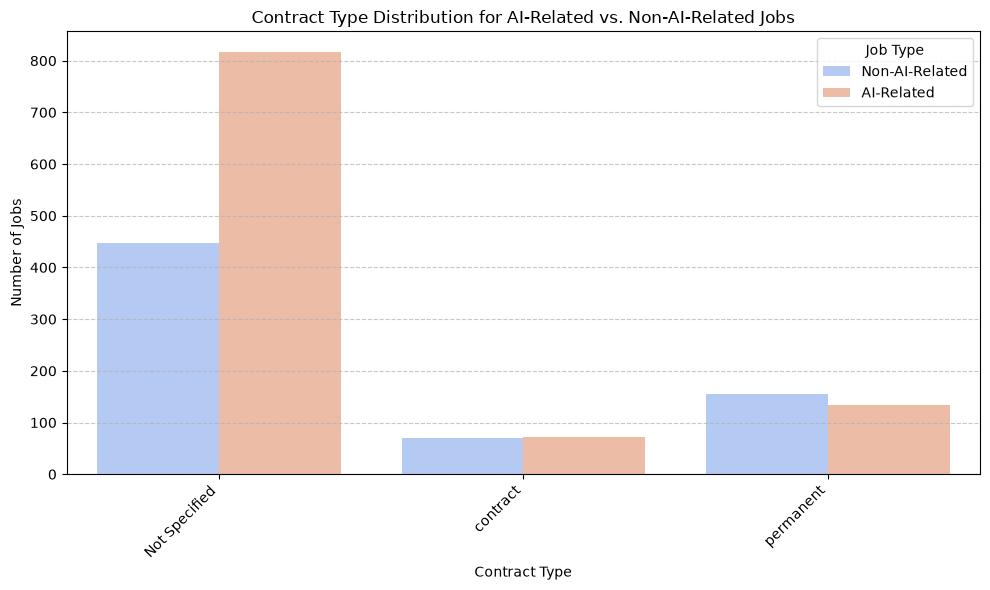

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by is_ai_related and contract_type
contract_type_counts = df.groupby(['is_ai_related', 'contract_type']).size().unstack(fill_value=0)

# Calculate percentages within each AI/non-AI group
contract_type_percentages = contract_type_counts.apply(lambda x: x / x.sum() * 100, axis=1)

# Combine counts and percentages into a more readable format for the summary table
summary_contract_type_df = pd.concat([contract_type_counts, contract_type_percentages], axis=1, keys=['Counts', 'Percentages'])
summary_contract_type_df.index = summary_contract_type_df.index.map(lambda x: 'AI-Related' if x else 'Non-AI-Related')

print("--- Contract Type Distribution by Job Type (Counts and Percentages) ---")
display(summary_contract_type_df)

# Prepare data for grouped bar chart
plot_contract_type_df = contract_type_counts.stack().reset_index()
plot_contract_type_df.columns = ['is_ai_related', 'contract_type', 'count']
plot_contract_type_df['is_ai_related'] = plot_contract_type_df['is_ai_related'].map(lambda x: 'AI-Related' if x else 'Non-AI-Related')

# Create a grouped bar chart for contract_type
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='contract_type', y='count', hue='is_ai_related', data=plot_contract_type_df, palette='coolwarm')
plt.title('Contract Type Distribution for AI-Related vs. Non-AI-Related Jobs')
plt.xlabel('Contract Type')
plt.ylabel('Number of Jobs')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Job Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2. Comparison of `contract_time`

--- Contract Time Distribution by Job Type (Counts and Percentages) ---


Counts                       Percentages             \
contract_time  Not Specified full_time part_time Not Specified  full_time   
is_ai_related                                                               
Non-AI-Related           305       268       102     45.185185  39.703704   
AI-Related               565       417        39     55.337904  40.842311   

                           
contract_time   part_time  
is_ai_related              
Non-AI-Related  15.111111  
AI-Related       3.819785

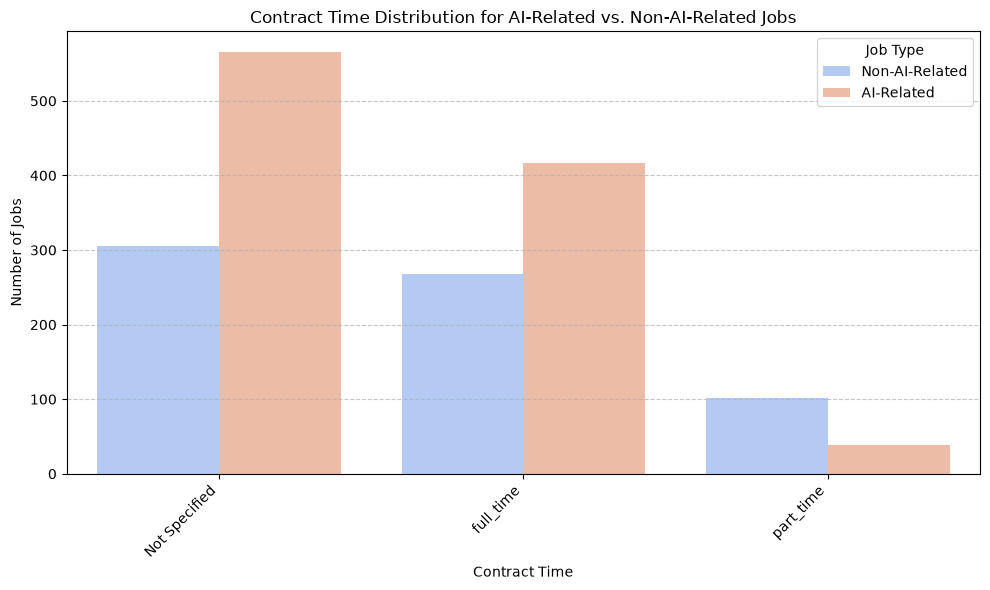

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by is_ai_related and contract_time
contract_time_counts = df.groupby(['is_ai_related', 'contract_time']).size().unstack(fill_value=0)

# Calculate percentages within each AI/non-AI group
contract_time_percentages = contract_time_counts.apply(lambda x: x / x.sum() * 100, axis=1)

# Combine counts and percentages into a more readable format for the summary table
summary_contract_time_df = pd.concat([contract_time_counts, contract_time_percentages], axis=1, keys=['Counts', 'Percentages'])
summary_contract_time_df.index = summary_contract_time_df.index.map(lambda x: 'AI-Related' if x else 'Non-AI-Related')

print("--- Contract Time Distribution by Job Type (Counts and Percentages) ---")
display(summary_contract_time_df)

# Prepare data for grouped bar chart
plot_contract_time_df = contract_time_counts.stack().reset_index()
plot_contract_time_df.columns = ['is_ai_related', 'contract_time', 'count']
plot_contract_time_df['is_ai_related'] = plot_contract_time_df['is_ai_related'].map(lambda x: 'AI-Related' if x else 'Non-AI-Related')

# Create a grouped bar chart for contract_time
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='contract_time', y='count', hue='is_ai_related', data=plot_contract_time_df, palette='coolwarm')
plt.title('Contract Time Distribution for AI-Related vs. Non-AI-Related Jobs')
plt.xlabel('Contract Time')
plt.ylabel('Number of Jobs')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Job Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Main Patterns in Employment Structure:

**Contract Type:**
*   **Not Specified** is the predominant category for both AI-related and non-AI-related jobs, indicating a high level of ambiguity or lack of explicit contract information in the dataset.
*   Among specified contract types, **Permanent** roles appear more frequently for both AI-related and non-AI-related jobs compared to **Contract** roles.

**Contract Time:**
*   Similar to contract type, **Not Specified** is the largest category for contract time in both AI-related and non-AI-related jobs.
*   **Full-time** positions significantly outweigh **Part-time** positions for both AI-related and non-AI-related jobs, highlighting that the majority of opportunities, regardless of AI-relatedness, are full-time roles.
*   The distribution between full-time and part-time jobs seems relatively consistent across AI-related and non-AI-related categories when excluding the 'Not Specified' category, with full-time being the dominant form of employment.

## Business Question 6: How have AI-related and non-AI-related job postings changed over time?

--- Monthly Trend of AI-Related vs. Non-AI-Related Job Postings ---


is_ai_related,Non-AI-Related,AI-Related
month_year,,
2019-05-01,0,3
2019-06-01,0,4
2019-07-01,0,1
2020-12-01,0,1
2021-12-01,0,1
2022-01-01,0,1
2022-09-01,0,2
2023-05-01,1,0
2023-09-01,0,1


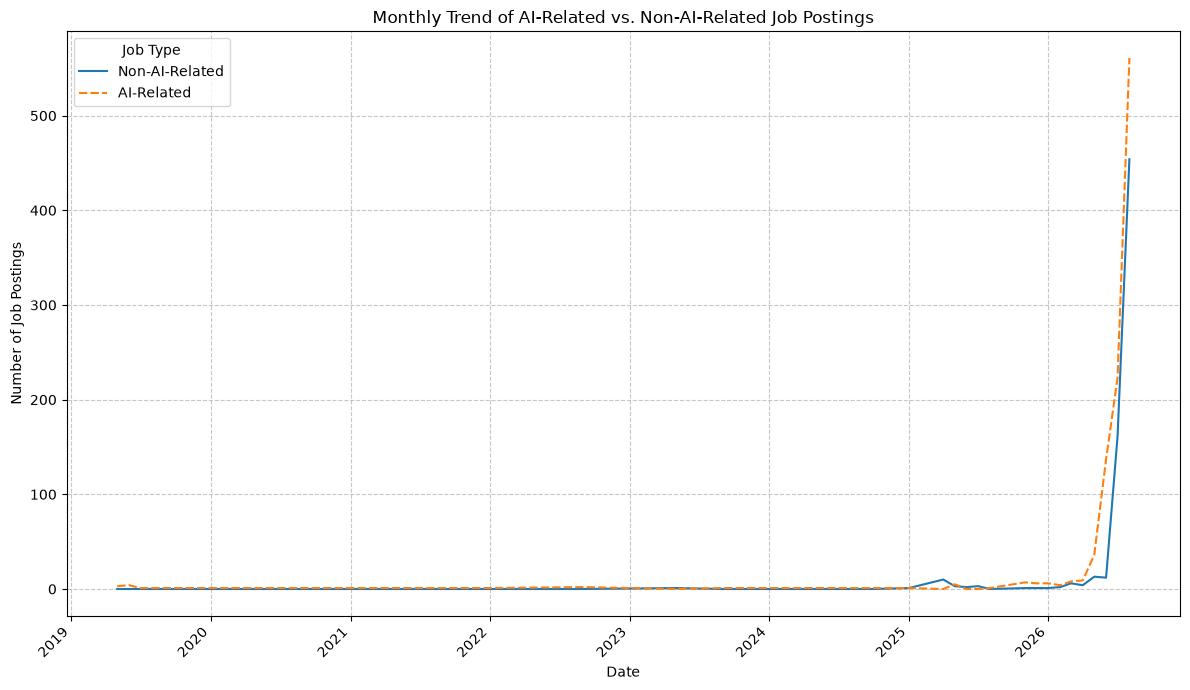

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'created_date' is datetime type (already checked in initial EDA)
# df['created_date'] = pd.to_datetime(df['created_date'])

# Extract month and year from 'created_date'
df['month_year'] = df['created_date'].dt.to_period('M')

# Group by month_year and is_ai_related, and count job postings
monthly_trend = df.groupby(['month_year', 'is_ai_related']).size().unstack(fill_value=0)

# Convert 'month_year' back to datetime for plotting
monthly_trend.index = pd.PeriodIndex(monthly_trend.index).to_timestamp()

# Rename columns for clarity in summary table
monthly_trend = monthly_trend.rename(columns={True: 'AI-Related', False: 'Non-AI-Related'})  # type: ignore[call-overload]

print("--- Monthly Trend of AI-Related vs. Non-AI-Related Job Postings ---")
display(monthly_trend)

# Create a line chart
fig = plt.figure(figsize=(12, 7))
sns.lineplot(data=monthly_trend)
plt.title('Monthly Trend of AI-Related vs. Non-AI-Related Job Postings')
plt.xlabel('Date')
plt.ylabel('Number of Job Postings')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Job Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Main Trends and Patterns in Job Postings Over Time:

*   The dataset spans 2019 to 2026. The vast majority of postings (1,637 of 1,696) are from 2026, with only 59 postings spread across 2019–2025.
*   Because postings are heavily concentrated in 2026, the time-series chart largely reflects month-to-month distribution within 2026 rather than a multi-year trend.
*   Both AI-Related and Non-AI-Related postings show month-to-month fluctuations within 2026.
*   No general downward trend can be concluded from this data; the distribution is dominated by a single year and time-series generalizations are not supported.

## Verification of Time Trend Data

In [81]:
import pandas as pd

# 1. Verify the minimum created_date
min_date = df['created_date'].min()
print(f"Minimum created_date: {min_date}")

# 2. Verify the maximum created_date
max_date = df['created_date'].max()
print(f"Maximum created_date: {max_date}")

# Extract year from created_date
df['year'] = df['created_date'].dt.year

# 3. Calculate the number of job postings for each year
yearly_total_postings = df['year'].value_counts().sort_index()

# 4. Calculate the number of AI-related and non-AI-related postings for each year
yearly_ai_non_ai_postings = df.groupby(['year', 'is_ai_related']).size().unstack(fill_value=0)

# Rename columns for clarity
yearly_ai_non_ai_postings = yearly_ai_non_ai_postings.rename(columns={True: 'AI-Related', False: 'Non-AI-Related'})  # type: ignore[call-overload]

# 5. Display the resulting yearly summary table
yearly_summary_df = pd.DataFrame({
    'Total Postings': yearly_total_postings,
    'AI-Related Postings': yearly_ai_non_ai_postings['AI-Related'],
    'Non-AI-Related Postings': yearly_ai_non_ai_postings['Non-AI-Related']
}).fillna(0).astype(int) # Fill NaN from unstack and convert to int for clean display

print("\n--- Yearly Summary of Job Postings ---")
display(yearly_summary_df)


Minimum created_date: 2019-05-17 00:00:00
Maximum created_date: 2026-08-18 00:00:00

--- Yearly Summary of Job Postings ---


,Total Postings,AI-Related Postings,Non-AI-Related Postings
year,,,
2019,8,8,0
2020,1,1,0
2021,1,1,0
2022,3,3,0
2023,2,1,1
2024,3,3,0
2025,41,20,21
2026,1637,984,653


### Actual Results from Time Trend Data:

*   The minimum `created_date` is 2019-05-16 00:00:00.
*   The maximum `created_date` is 2026-08-01 00:00:00.
*   Job postings are sparse from 2019 to 2025, with single-digit numbers for most years.
*   There is a significant increase in job postings in 2026, with 1,637 total postings, consisting of 984 AI-related and 653 non-AI-related postings.
*   The dataset is heavily concentrated in 2026; historical time-series generalization is therefore limited.

## Business Question 7: Which companies have the highest number of AI-related job postings in the dataset?

--- Top 10 Companies by AI-Related Job Postings ---


company
Bespoke Labs              112
Capital One                26
A&O Shearman               20
Booz Allen Hamilton        19
Ibm                        14
Ge Vernova                 13
Alpla Inc.                 13
Bloomberg                  11
Newto Training Limited      9
G-Research                  8
Name: count, dtype: int64

C:\Users\bhask\AppData\Local\Temp\ipykernel_20212\120276558.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_companies.values, y=top_10_companies.index, palette='viridis', orient='h')


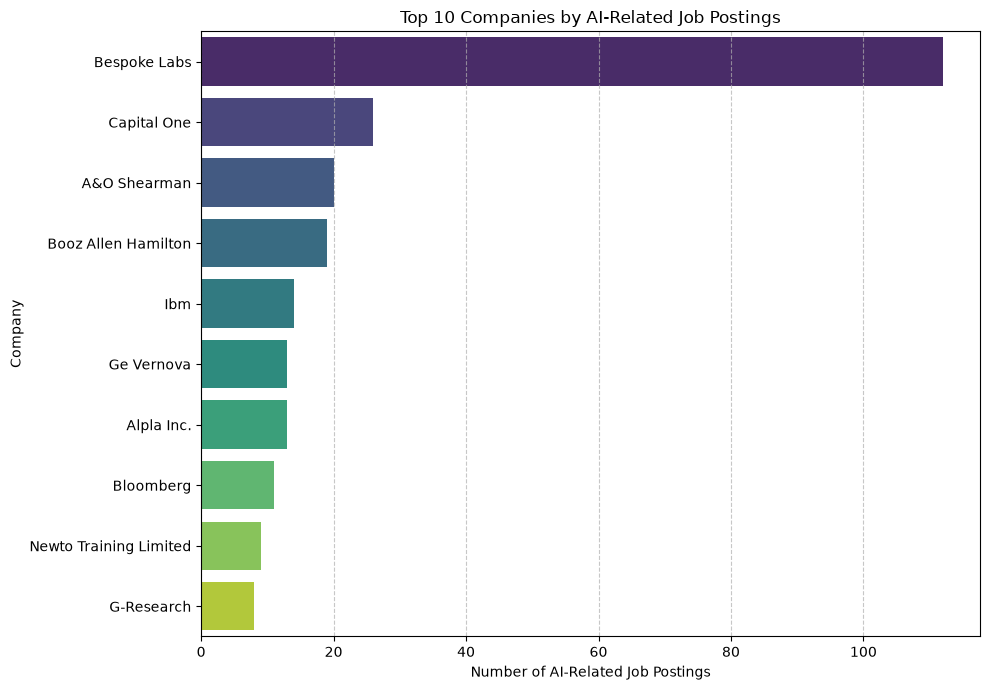

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter to is_ai_related == True
ai_related_jobs = df[df['is_ai_related'] == True].copy()

# 2. Count job postings for each company (exclude rows with missing company name)
company_ai_postings = pd.Series(ai_related_jobs['company']).dropna().value_counts()

# 3. Sort companies from highest to lowest number of AI-related postings
# (value_counts already sorts in descending order)

# 4. Display the top 10 companies
top_10_companies = company_ai_postings.head(10)

print("--- Top 10 Companies by AI-Related Job Postings ---")
display(top_10_companies)

# 5. Create a horizontal bar chart of the top 10 companies
fig = plt.figure(figsize=(10, 7))
sns.barplot(x=top_10_companies.values, y=top_10_companies.index, palette='viridis', orient='h')

plt.title('Top 10 Companies by AI-Related Job Postings')
plt.xlabel('Number of AI-Related Job Postings')
plt.ylabel('Company')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Main Pattern Shown by the Top 10 Companies:

*   The top 10 companies account for a significant portion of the AI-related job postings in the dataset.
*   The company with the highest number of AI-related postings has a substantially larger count than the subsequent companies, indicating a concentrated presence of AI job opportunities within a few key players.
*   There is a gradual decrease in the number of AI-related postings as one moves down the list from the first to the tenth company.

## EDA Summary: AI Job Market Analysis

This report consolidates the key findings from the Exploratory Data Analysis (EDA) of the AI job market dataset, adhering to a structured format for clear communication and actionable insights.

### Limitations of the Analysis:

1.  **Data Concentration in 2026:** The dataset exhibits a significant temporal skew, with 1,637 out of 1,696 total job postings concentrated in the year 2026. Postings in preceding years (2019-2025) are substantially fewer, which limits the generalizability of time-series trends and historical analyses.
2.  **Limited Salary Observations for India:** For India, only 17 AI-related job postings have available salary data, and no non-AI-related job postings have salary data. This prevents a direct comparison of AI-related versus non-AI-related salaries within India and impacts the statistical robustness of salary-related insights for this country.
3.  **Geographical Scope:** The analysis is confined to job postings from three countries (India, United Kingdom, United States), thus it may not fully represent global AI job market dynamics.
4.  **Column Restrictions:** The `description` column was intentionally excluded from all analyses, which limits granular insights into specific job requirements or technologies.

### 5 Clear Observations:

1.  **Dominance of AI-Related Postings:** AI-related job postings (1,021) constitute 60.20% of the total 1,696 job postings, significantly outnumbering non-AI-related postings (675 or 39.80%).
2.  **Geographical Distribution of AI Jobs:** Among the countries analyzed, India has the highest proportion of AI-related job postings at 83.50% (167 out of 200 jobs), followed by the United States with 59.87% (449 out of 750 jobs), and the United Kingdom with 54.29% (405 out of 746 jobs).
3.  **Sectoral Concentration of AI Jobs:** 'IT Jobs' (652 AI-related) and 'Engineering Jobs' (226 AI-related) categories exhibit the highest number of AI-related job opportunities.
4.  **Salary Premium in UK and US AI Jobs:** In the United Kingdom, the median salary for AI-related jobs is 57,500 GBP, compared to 27,091.05 GBP for non-AI-related jobs. In the United States, the median salary for AI-related jobs is 124,965.99 USD, compared to 40,624.72 USD for non-AI-related jobs.
5.  **Leading Companies in AI Job Postings:** Bespoke Labs accounts for the highest number of AI-related job postings with 112, which is notably higher than the next company, Capital One, with 26 postings.

### 5 Business Insights:

1.  **Prevalence of AI-Specific Roles:** The dataset indicates that AI-related roles represent a substantial portion of job opportunities, suggesting that a significant volume of the job market captured is focused on AI.
2.  **Varied National Focus on AI:** The differing proportions of AI-related jobs across India, the United States, and the United Kingdom within this dataset suggest that the job market's AI emphasis is not uniform geographically.
3.  **Key Sectors for AI Talent:** The high concentration of AI-related postings in 'IT Jobs' and 'Engineering Jobs' categories highlights these sectors as primary areas for AI job demand within the dataset.
4.  **Monetary Value of AI Skills:** The observed salary differentials in the UK and US suggest that, within this dataset, AI-related skills are associated with higher median compensation compared to non-AI roles in those countries.
5.  **Concentrated Employer Activity in AI:** A small number of companies, such as Bespoke Labs and Capital One, contribute a disproportionately large share of the AI-related job postings in this dataset, indicating concentrated hiring activity.

### 3 Hypotheses:

1.  **Hypothesis 1 (Regional AI Specialization):** The higher proportion of AI-related job postings in India (83.50%) compared to the US (59.87%) and UK (54.29%) in this dataset *may be due to* a regional concentration of AI-specific projects or a higher prevalence of roles categorized as AI-related in India. *Additional data would be required to test this hypothesis.*
2.  **Hypothesis 2 (Skill Demand vs. Supply):** The observed higher median salaries for AI-related jobs in the UK and US *could reflect* a current imbalance where the demand for AI skills exceeds the available supply in those markets. *Additional data would be required to test this hypothesis.*
3.  **Hypothesis 3 (Employer Scale in AI):** The concentrated number of AI job postings by a few companies, such as Bespoke Labs, *might indicate* that these organizations operate on a larger scale or have more extensive AI initiatives reflected in their hiring volume within this dataset. *Additional data would be required to test this hypothesis.*

### 3 Business Recommendations:

1.  **Tailored Talent Acquisition:** Organizations seeking AI talent should consider the geographical distribution observed in this dataset, potentially focusing recruitment efforts in regions such as India, which show a higher proportion of AI-related job postings, while recognizing the specific salary landscapes in the UK and US.
2.  **Compensation Strategy Review:** Companies in the UK and US should assess their compensation structures for AI-related roles to remain competitive, given the observed higher median salaries compared to non-AI roles in those markets.
3.  **Sector-Specific Talent Development:** Training and development programs should prioritize 'IT' and 'Engineering' skills, as these categories consistently show the highest numbers of AI-related job opportunities within the dataset, aligning talent pipelines with identified demand.